# BS-ANN — Implied Volatility Training


## Setup
_Run this cell first. It pulls the shared repo code and imports it._


In [ ]:
# === Setup: pull shared code and import (run first) ===
from google.colab import drive; drive.mount('/content/drive')
import os
REPO_URL = 'https://github.com/JosephOuyang/machine_learning_for_implied_volatility_forecasting.git'
REPO_DIR = '/content/repo'
if os.path.isdir(REPO_DIR):
    os.system(f'cd {REPO_DIR} && git pull -q')
else:
    os.system(f'git clone -q {REPO_URL} {REPO_DIR}')
import sys; sys.path.insert(0, REPO_DIR)
from shared.setup import *   # imports, seeds, logger, Drive mount


# BS-ANN — Implied Volatility Training

Transformed IV MLP training (Week 13). Self-contained.


## Implied Volatility


In [ ]:
# =========================
# CELL 13.0 — Week 13 START (Transformed Implied Volatility: MLP Sweep)
# =========================
run_dir_w13, fig_dir_w13 = start_run("week13_transformed_iv_mlp_sweep")
print("run_dir_w13:", run_dir_w13)
print("fig_dir_w13:", fig_dir_w13)

save_json(run_dir_w13, "params", {
    "week": 13,
    "goal": (
        "Partial replication of Table 6.25 of Della Corte et al. (2025): "
        "6-model MLP sweep on the transformed implied volatility problem "
        "(scaled time value + log-transform). "
        "Architectures selected to cover low-to-mid capacity range at both "
        "depths while keeping compute feasible. High-capacity results "
        "(250N, 500N) taken directly from the paper."
    ),
    "problem": "Transformed Implied Volatility (BS synthetic data)",
    "transformation": {
        "step1": "Compute scaled time value: pi_hat/K = (pi/K) - max(m - exp(-r*tau), 0)",
        "step2": "Apply log-transform: input x4 = log(pi_hat/K)",
        "input_range_log_scaled_tv": "[-18.42, -0.95]  (Table 5.14)",
        "output": "Volatility sigma in (0.01, 1.0)",
    },
    "dataset": {
        "n_total":        1_000_000,
        "train":            800_000,
        "val":              200_000,
        "test_separate":    100_000,
        "sampling":       "Latin Hypercube Sampling (LHS)",
        "source":         "Synthetic Black-Scholes (Section 5.1 / Table 5.11)",
    },
    "input_ranges_raw_bs": {
        "m = S/K": [0.4, 1.6],
        "tau":     [0.2, 1.1],
        "r":       [0.02, 0.10],
        "sigma":   [0.01, 1.0],
    },
    "configs_trained": [
        {"layers": 2, "nodes":  50, "rationale": "baseline floor, worst performer"},
        {"layers": 2, "nodes": 100, "rationale": "first jump in 2-layer series"},
        {"layers": 2, "nodes": 150, "rationale": "Week 7 architecture — cross-week continuity"},
        {"layers": 3, "nodes":  50, "rationale": "3-layer floor, depth comparison vs 2L-50N"},
        {"layers": 3, "nodes": 100, "rationale": "mirrors 2L-100N for depth comparison"},
        {"layers": 3, "nodes": 150, "rationale": "direct depth comparison vs 2L-150N"},
    ],
    "configs_omitted_taken_from_paper": [
        {"layers": 2, "nodes": 200}, {"layers": 2, "nodes": 250},
        {"layers": 2, "nodes": 500}, {"layers": 3, "nodes": 200},
        {"layers": 3, "nodes": 250}, {"layers": 3, "nodes": 500},
    ],
    "hyperparams": {
        "activation":    "ReLU",
        "loss":          "MSE",
        "lr":            1e-5,
        "batch_size":    64,
        "epochs":        200,
        "adam_epsilon":  1e-7,
        "initializer":   "Xavier Normal (Glorot)",
        "device":        "cpu",
        "torch_threads": 1,
    },
    "paper_reference": "Della Corte et al. (2025), Table 6.25",
    "paper_best_mse":  1.6e-7,
    "paper_best_arch": "3 layers, 500 nodes",
})

save_notes(run_dir_w13, """
Week 13 (Transformed IV MLP sweep) deliverables:

Background
- The 'raw' IV problem (σ = f^{-1}(π/K)) suffers from exploding gradients
  wherever vega ≈ 0 (deep ITM / deep OTM). dσ/dπ = 1/vega → ∞.
- Liu et al. [22] / Della Corte et al. (2025) Section 5.2 fix:
    1. Subtract intrinsic value to get scaled time value π̂/K.
    2. Apply log-transform → input x4 = log(π̂/K) in [-18.42, -0.95].
  This squashes the gradient and dramatically improves training stability.

Architectures trained (6 of 12)
  2L  50N — baseline floor
  2L 100N — first jump in 2-layer series
  2L 150N — Week 7 architecture (cross-week continuity)
  3L  50N — 3-layer floor
  3L 100N — depth comparison vs 2L 100N
  3L 150N — depth comparison vs 2L 150N (paper: 1.9e-6 vs 1.5e-6)
  Omitted 6 configs (200N, 250N, 500N for both depths) — taken from paper.

Data pipeline
1. Generate 1M LHS samples of (m, tau, r, sigma) using BS ranges (Table 5.11).
2. Compute π/K via bs_moneyness_call (same as Weeks 2-7).
3. Subtract scaled intrinsic: π̂/K = π/K - max(m - exp(-r*tau), 0).
4. Drop any rows where π̂/K <= 0 (can't log-transform).
5. Input x4 = log(π̂/K). Final input: (m, tau, r, log(π̂/K)). Label: sigma.
6. Split: 800k train / 200k val (paper Section 5.3).
7. Separate 100k LHS test set generated independently.

Artifacts
- week13_transformed_iv_mlp_sweep.csv
- week13_fig6_24_style_time_vs_mse.png
- week13_train/val_curves_*.png
- week13_paper_comparison_table.csv
- notes_week13_summary.md
""")

print("Week 13 logger ready ✅")

run_dir_w13: runs/week13_transformed_iv_mlp_sweep/20260518-020229
fig_dir_w13: runs/week13_transformed_iv_mlp_sweep/20260518-020229/figures
Week 13 logger ready ✅


In [ ]:
# =========================
# CELL 13.1 — Imports (self-contained)
# =========================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json, os, time

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from scipy.stats import qmc, norm

# ── reproducibility ────────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── device & thread count ─────────────────────────────────────────────────────
device = torch.device("cpu")
torch.set_num_threads(1)
print("device:", device, "| torch threads:", torch.get_num_threads())

# ── paper hyperparams ─────────────────────────────────────────────────────────
PAPER_LR     = 1e-5
PAPER_BATCH  = 64
PAPER_EPOCHS = 200
ADAM_EPS     = 1e-7    # matches TensorFlow default (used since Week 7)

print(f"LR={PAPER_LR} | batch={PAPER_BATCH} | epochs={PAPER_EPOCHS} | eps={ADAM_EPS}")
print("Imports ready ✅")

device: cpu | torch threads: 1
LR=1e-05 | batch=64 | epochs=200 | eps=1e-07
Imports ready ✅


In [ ]:
# =========================
# CELL 13.2 — PaperMLP Class (self-contained re-declaration)
# =========================

class PaperMLP(nn.Module):
    """
    Paper-aligned MLP (Della Corte et al. 2025, Table 6.15 / 6.25).
      hidden_layers : 2 or 3
      hidden_units  : nodes per hidden layer
      in_dim        : 4  (m, tau, r, log(pi_hat/K))
      out           : 1  (sigma)
      activation    : ReLU
      init          : Xavier Normal (Glorot)
    """
    def __init__(self, hidden_layers: int, hidden_units: int, in_dim: int = 4):
        super().__init__()
        assert hidden_layers in (2, 3), "hidden_layers must be 2 or 3"

        layers = []
        d = in_dim
        for _ in range(hidden_layers):
            layers.append(nn.Linear(d, hidden_units))
            layers.append(nn.ReLU())
            d = hidden_units
        layers.append(nn.Linear(d, 1))
        self.net = nn.Sequential(*layers)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x).squeeze(-1)

    def count_params(self):
        return sum(p.numel() for p in self.parameters())


# ── Sanity check: 2L 50N must have 2,851 params (matches paper Table 6.25) ───
_m = PaperMLP(hidden_layers=2, hidden_units=50, in_dim=4)
assert _m.count_params() == 2_851, f"Unexpected param count: {_m.count_params()}"
del _m
print("PaperMLP defined and verified ✅")

PaperMLP defined and verified ✅


In [ ]:
# =========================
# CELL 13.3 — Transformed IV Dataset Generator
# =========================
# Implements the two-step transformation from Section 5.2 / Table 5.14:
#   Step 1: Scaled time value  π̂/K = π/K − max(m − e^{−r·τ}, 0)
#   Step 2: Log-transform      x4   = log(π̂/K)
#
# Raw BS input ranges (Table 5.11):
#   m ∈ [0.4,1.6], tau ∈ [0.2,1.1], r ∈ [0.02,0.10], sigma ∈ [0.01,1.0]
# After transformation (Table 5.14):
#   log(π̂/K) ∈ [−18.42, −0.95]
# Label: sigma ∈ (0.01, 1.0)

LOG_FLOOR = -19.0    # slightly below paper's reported minimum of -18.42

def bs_transformed_iv_lhs_generator(n: int = 1_000_000, seed: int = SEED):
    """
    Generate n LHS samples for the transformed implied volatility problem.

    Returns
    -------
    X         : np.ndarray (n_valid, 4)  — [m, tau, r, log(π̂/K)]
    y         : np.ndarray (n_valid,)    — sigma (label)
    n_dropped : int                      — rows removed (pi_hat_K <= 0 or log below floor)
    """
    lo = np.array([0.4,  0.2,  0.02, 0.01])
    hi = np.array([1.6,  1.1,  0.10, 1.00])

    sampler = qmc.LatinHypercube(d=4, seed=seed)
    raw     = qmc.scale(sampler.random(n), lo, hi)

    m     = raw[:, 0]
    tau   = raw[:, 1]
    r     = raw[:, 2]
    sigma = raw[:, 3]    # becomes the LABEL

    # ── Black-Scholes scaled call price π/K ───────────────────────────────────
    sqrt_tau      = np.sqrt(tau)
    sigma_sqrttau = np.maximum(sigma * sqrt_tau, 1e-8)

    d1   = (np.log(m) + (r + 0.5 * sigma**2) * tau) / sigma_sqrttau
    d2   = d1 - sigma_sqrttau
    pi_K = m * norm.cdf(d1) - np.exp(-r * tau) * norm.cdf(d2)

    # ── Step 1: subtract scaled intrinsic value ───────────────────────────────
    intrinsic = np.maximum(m - np.exp(-r * tau), 0.0)
    pi_hat_K  = pi_K - intrinsic

    # ── Compute log, guard against non-positive values ────────────────────────
    log_pi_hat_K_raw = np.where(pi_hat_K > 0, np.log(pi_hat_K), -np.inf)

    # ── Drop rows where time value is non-positive or log is below floor ──────
    valid     = (pi_hat_K > 0) & (log_pi_hat_K_raw >= LOG_FLOOR)
    n_dropped = int((~valid).sum())

    m            = m[valid]
    tau          = tau[valid]
    r            = r[valid]
    sigma        = sigma[valid]
    log_pi_hat_K = log_pi_hat_K_raw[valid]

    # ── Sanity checks ─────────────────────────────────────────────────────────
    assert np.all(np.isfinite(log_pi_hat_K)), "Non-finite values in log(π̂/K)"
    assert log_pi_hat_K.min() >= LOG_FLOOR,   "Log floor not enforced correctly"
    assert np.all(sigma > 0),                 "Sigma must be positive"
    assert np.all(tau   > 0),                 "Tau must be positive"
    assert np.all(m     > 0),                 "Moneyness must be positive"

    X = np.column_stack([m, tau, r, log_pi_hat_K]).astype(np.float32)
    y = sigma.astype(np.float32)

    return X, y, n_dropped


# ── Verification test ─────────────────────────────────────────────────────────
_X, _y, _d = bs_transformed_iv_lhs_generator(n=5_000, seed=SEED)
print("Generator test (n=5,000):")
print(f"  X shape:            {_X.shape}")
print(f"  y shape:            {_y.shape}")
print(f"  rows dropped:       {_d}")
print(f"  log(π̂/K) range:    [{_X[:,3].min():.4f}, {_X[:,3].max():.4f}]")
print(f"  Paper Table 5.14:  [-18.42, -0.95]")
print(f"  sigma range:        [{_y.min():.4f}, {_y.max():.4f}]")
del _X, _y, _d

print("\nbs_transformed_iv_lhs_generator defined ✅")

Generator test (n=5,000):
  X shape:            (4612, 4)
  y shape:            (4612,)
  rows dropped:       388
  log(π̂/K) range:    [-18.9577, -1.0374]
  Paper Table 5.14:  [-18.42, -0.95]
  sigma range:        [0.0124, 0.9999]

bs_transformed_iv_lhs_generator defined ✅


/tmp/ipykernel_1280/2282835566.py:50: RuntimeWarning: divide by zero encountered in log
  log_pi_hat_K_raw = np.where(pi_hat_K > 0, np.log(pi_hat_K), -np.inf)
/tmp/ipykernel_1280/2282835566.py:50: RuntimeWarning: invalid value encountered in log
  log_pi_hat_K_raw = np.where(pi_hat_K > 0, np.log(pi_hat_K), -np.inf)


In [ ]:
# =========================
# CELL 13.4 — Generate Datasets and Build DataLoaders
# =========================
# Paper Section 5.3 protocol:
#   1M LHS → 800k train / 200k val  +  separate independent 100k test set.
#
# We request ~9% more samples than needed to absorb dropped rows and
# guarantee the paper's exact split sizes after filtering.

N_TOTAL_REQUEST  = 1_100_000   # request ~1.1M to guarantee 1M clean rows
N_TEST_REQUEST   =   110_000   # request ~110k to guarantee 100k clean rows

print(f"Generating {N_TOTAL_REQUEST:,} LHS samples for train/val "
      f"(targeting 1M clean rows)...")
t0 = time.perf_counter()

X_trainval, y_trainval, dropped_tv = bs_transformed_iv_lhs_generator(
    n=N_TOTAL_REQUEST, seed=SEED
)

print(f"  Done in {time.perf_counter()-t0:.1f}s")
print(f"  Clean rows: {len(X_trainval):,}  |  rows dropped: {dropped_tv}")
print(f"  log(π̂/K) range: [{X_trainval[:,3].min():.4f}, {X_trainval[:,3].max():.4f}]")
print(f"  Paper expected:  [-18.42, -0.95]")
print(f"  sigma range:     [{y_trainval.min():.4f}, {y_trainval.max():.4f}]")

assert len(X_trainval) >= 1_000_000, (
    f"Only {len(X_trainval):,} clean rows — increase N_TOTAL_REQUEST"
)

# ── Train / Val split (800k / 200k, paper-exact) ─────────────────────────────
n_train = 800_000
n_val   = 200_000

X_train = X_trainval[:n_train];         y_train = y_trainval[:n_train]
X_val   = X_trainval[n_train:n_train+n_val]; y_val = y_trainval[n_train:n_train+n_val]

print(f"\nSplit: train={len(X_train):,}  val={len(X_val):,}")
assert len(X_train) == 800_000, "Train set not 800k"
assert len(X_val)   == 200_000, "Val set not 200k"

# ── Separate 100k test set (independent seed) ─────────────────────────────────
print(f"\nGenerating {N_TEST_REQUEST:,} LHS samples for test "
      f"(targeting 100k clean rows)...")
t1 = time.perf_counter()

X_test_raw, y_test_raw, dropped_test = bs_transformed_iv_lhs_generator(
    n=N_TEST_REQUEST, seed=SEED + 1
)

print(f"  Done in {time.perf_counter()-t1:.1f}s")
print(f"  Clean rows: {len(X_test_raw):,}  |  rows dropped: {dropped_test}")
print(f"  log(π̂/K) range: [{X_test_raw[:,3].min():.4f}, {X_test_raw[:,3].max():.4f}]")

assert len(X_test_raw) >= 100_000, (
    f"Only {len(X_test_raw):,} clean rows — increase N_TEST_REQUEST"
)

# Trim to exactly 100k
X_test = X_test_raw[:100_000]
y_test = y_test_raw[:100_000]
print(f"  Test set trimmed to exactly: {len(X_test):,}")

# ── DataLoaders ───────────────────────────────────────────────────────────────
g_loader = torch.Generator().manual_seed(SEED)

train_ds_w13 = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
val_ds_w13   = TensorDataset(torch.tensor(X_val),   torch.tensor(y_val))
test_ds_w13  = TensorDataset(torch.tensor(X_test),  torch.tensor(y_test))

train_loader_w13 = DataLoader(
    train_ds_w13, batch_size=PAPER_BATCH,
    shuffle=True, drop_last=True, generator=g_loader
)
val_loader_w13  = DataLoader(val_ds_w13,  batch_size=PAPER_BATCH, shuffle=False)
test_loader_w13 = DataLoader(test_ds_w13, batch_size=PAPER_BATCH, shuffle=False)

print(f"\nDataLoaders ready ✅")
print(f"  Train batches: {len(train_loader_w13):,}")
print(f"  Val   batches: {len(val_loader_w13):,}")
print(f"  Test  batches: {len(test_loader_w13):,}")

save_json(run_dir_w13, "dataset_summary", {
    "n_trainval_requested": int(N_TOTAL_REQUEST),
    "n_dropped_trainval":   int(dropped_tv),
    "n_train":              int(n_train),
    "n_val":                int(n_val),
    "n_test_requested":     int(N_TEST_REQUEST),
    "n_dropped_test":       int(dropped_test),
    "n_test_actual":        int(len(X_test)),
    "log_floor":            float(LOG_FLOOR),
    "features":             ["m (moneyness)", "tau", "r", "log(pi_hat/K)"],
    "label":                "sigma (implied volatility)",
    "seed_trainval":        int(SEED),
    "seed_test":            int(SEED + 1),
})

Generating 1,100,000 LHS samples for train/val (targeting 1M clean rows)...
  Done in 0.2s
  Clean rows: 1,013,739  |  rows dropped: 86261
  log(π̂/K) range: [-18.9994, -0.9478]
  Paper expected:  [-18.42, -0.95]
  sigma range:     [0.0100, 1.0000]

Split: train=800,000  val=200,000

Generating 110,000 LHS samples for test (targeting 100k clean rows)...
  Done in 0.0s
  Clean rows: 101,380  |  rows dropped: 8620
  log(π̂/K) range: [-18.9993, -0.9874]
  Test set trimmed to exactly: 100,000

DataLoaders ready ✅
  Train batches: 12,500
  Val   batches: 3,125
  Test  batches: 1,563


/tmp/ipykernel_1280/2282835566.py:50: RuntimeWarning: divide by zero encountered in log
  log_pi_hat_K_raw = np.where(pi_hat_K > 0, np.log(pi_hat_K), -np.inf)
/tmp/ipykernel_1280/2282835566.py:50: RuntimeWarning: invalid value encountered in log
  log_pi_hat_K_raw = np.where(pi_hat_K > 0, np.log(pi_hat_K), -np.inf)


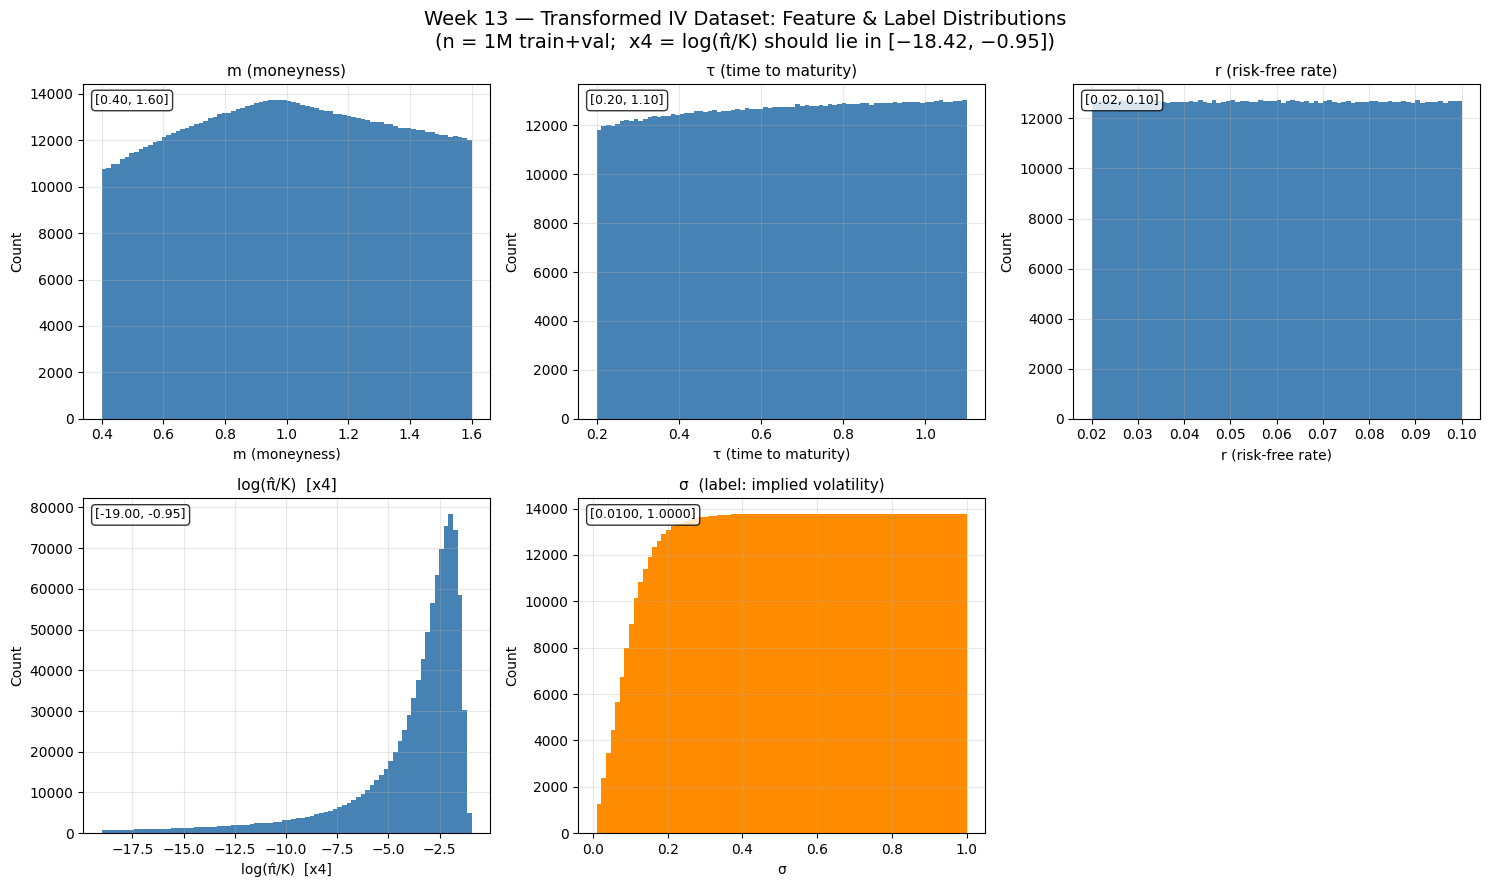

Saved: runs/week13_transformed_iv_mlp_sweep/20260518-020229/figures/week13_transformed_iv_distributions.png

Feature ranges (train+val):
  m                   : [0.4000,  1.6000]
  tau                 : [0.2000,  1.1000]
  r                   : [0.0200,  0.1000]
  log(pi_hat/K)       : [-18.9994,  -0.9478]
  sigma (label)       : [0.0100,  1.0000]

Paper Table 5.14 expected:  log(π̂/K) ∈ [-18.42, -0.95]  |  σ ∈ (0.01, 1.0)


In [ ]:
# =========================
# CELL 13.5 — EDA: Feature and Label Distributions
# =========================

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle(
    "Week 13 — Transformed IV Dataset: Feature & Label Distributions\n"
    "(n = 1M train+val;  x4 = log(π̂/K) should lie in [−18.42, −0.95])",
    fontsize=14
)

col_names = [
    "m (moneyness)", "τ (time to maturity)",
    "r (risk-free rate)", "log(π̂/K)  [x4]",
]
eda_colors = ["steelblue", "steelblue", "steelblue", "steelblue",
              "darkorange", "green"]

for i, (name, col) in enumerate(zip(col_names, range(4))):
    ax = axes[i // 3][i % 3]
    ax.hist(X_trainval[:, col], bins=80, color=eda_colors[i], edgecolor='none')
    ax.set_title(name, fontsize=11)
    ax.set_xlabel(name)
    ax.set_ylabel("Count")
    ax.grid(True, alpha=0.3)
    lo_v = float(X_trainval[:, col].min())
    hi_v = float(X_trainval[:, col].max())
    ax.text(0.03, 0.97, f"[{lo_v:.2f}, {hi_v:.2f}]",
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ── Label: sigma ──────────────────────────────────────────────────────────────
ax_s = axes[1][1]
ax_s.hist(y_trainval, bins=80, color='darkorange', edgecolor='none')
ax_s.set_title("σ  (label: implied volatility)", fontsize=11)
ax_s.set_xlabel("σ"); ax_s.set_ylabel("Count")
ax_s.grid(True, alpha=0.3)
ax_s.text(0.03, 0.97,
          f"[{y_trainval.min():.4f}, {y_trainval.max():.4f}]",
          transform=ax_s.transAxes, va='top', fontsize=9,
          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

axes[1][2].set_visible(False)

plt.tight_layout()
eda_path = os.path.join(fig_dir_w13, "week13_transformed_iv_distributions.png")
plt.savefig(eda_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", eda_path)

print("\nFeature ranges (train+val):")
for i, fname in enumerate(["m", "tau", "r", "log(pi_hat/K)"]):
    print(f"  {fname:20s}: [{X_trainval[:,i].min():.4f},  {X_trainval[:,i].max():.4f}]")
print(f"  {'sigma (label)':20s}: [{y_trainval.min():.4f},  {y_trainval.max():.4f}]")
print("\nPaper Table 5.14 expected:  log(π̂/K) ∈ [-18.42, -0.95]  |  σ ∈ (0.01, 1.0)")

In [ ]:
# =========================
# CELL 13.6 — MSE Evaluation Helper
# =========================

@torch.no_grad()
def eval_avg_mse_iv(model, loader, device):
    """Return average MSE (SSE / N) over an entire DataLoader."""
    model.eval()
    sse, n = 0.0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        sse += F.mse_loss(model(X_b), y_b, reduction="sum").item()
        n   += X_b.size(0)
    return sse / max(n, 1)

print("eval_avg_mse_iv defined ✅")

eval_avg_mse_iv defined ✅


In [ ]:
# =========================
# CELL 13.7 — Training Function (resume-safe, cumulative timing)
# =========================

def train_week13(
    model,
    train_loader,
    val_loader,
    test_loader,
    tag,
    run_dir,
    fig_dir,
    epochs   = PAPER_EPOCHS,
    lr       = PAPER_LR,
    adam_eps = ADAM_EPS,
):
    """
    Train a PaperMLP for the transformed IV problem.

    Resume-safe: restores model weights, optimizer state, loss curves,
    best_val, and cumulative wall-clock time from a rolling checkpoint.
    Overwrites a single checkpoint file each epoch to save disk space.

    Returns: results dict
    """
    _device = torch.device("cpu")
    torch.set_num_threads(1)
    model = model.to(_device)

    opt = torch.optim.Adam(model.parameters(), lr=lr, eps=adam_eps)

    ckpt_path = os.path.join(run_dir, f"checkpoint_{tag}.pt")
    best_path = os.path.join(run_dir, f"model_best_{tag}.pt")

    start_epoch        = 1
    train_curve        = []
    val_curve          = []
    best_val           = float("inf")
    cumulative_seconds = 0.0

    # ── Resume logic ──────────────────────────────────────────────────────────
    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location="cpu")
        model.load_state_dict(ckpt["model_state"])
        opt.load_state_dict(ckpt["opt_state"])
        start_epoch        = int(ckpt["epoch"]) + 1
        train_curve        = list(ckpt["train_curve"])
        val_curve          = list(ckpt["val_curve"])
        best_val           = float(ckpt["best_val"])
        cumulative_seconds = float(ckpt.get("cumulative_seconds", 0.0))
        print(f"✅ Resumed {tag} from epoch {ckpt['epoch']}  "
              f"(cumulative time so far: {cumulative_seconds/3600:.4f}h)")
    else:
        print(f"ℹ️  Training {tag} from scratch  "
              f"({model.count_params():,} params)")

    # ── Training loop ─────────────────────────────────────────────────────────
    t0 = time.perf_counter()

    for ep in range(start_epoch, epochs + 1):
        model.train()
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(_device), y_b.to(_device)
            opt.zero_grad(set_to_none=True)
            F.mse_loss(model(X_b), y_b).backward()
            opt.step()

        train_mse = eval_avg_mse_iv(model, train_loader, _device)
        val_mse   = eval_avg_mse_iv(model, val_loader,   _device)
        train_curve.append(float(train_mse))
        val_curve.append(float(val_mse))

        # Track best weights by validation MSE
        if val_mse < best_val:
            best_val = val_mse
            torch.save(model.state_dict(), best_path)

        if ep % 50 == 0 or ep in (1, epochs):
            print(f"  {tag} | ep {ep:3d}/{epochs} | "
                  f"train={train_mse:.3e} | val={val_mse:.3e}")

        # Rolling checkpoint — overwrites same file each epoch
        elapsed = time.perf_counter() - t0
        torch.save({
            "epoch":              int(ep),
            "model_state":        {k: v.detach().cpu().clone()
                                   for k, v in model.state_dict().items()},
            "opt_state":          opt.state_dict(),
            "train_curve":        [float(x) for x in train_curve],
            "val_curve":          [float(x) for x in val_curve],
            "best_val":           float(best_val),
            "cumulative_seconds": float(cumulative_seconds + elapsed),
            "tag":                str(tag),
        }, ckpt_path)

        # Progress snapshot (overwritten each epoch — cheap disk write)
        save_json(run_dir, f"metrics_progress_{tag}", {
            "epoch":        int(ep),
            "train_mse":    float(train_mse),
            "val_mse":      float(val_mse),
            "best_val_mse": float(best_val),
            "hours_so_far": float((cumulative_seconds + elapsed) / 3600.0),
            "tag":          str(tag),
        })

    total_seconds = cumulative_seconds + (time.perf_counter() - t0)

    # ── Evaluate best model on held-out test set ──────────────────────────────
    model.load_state_dict(torch.load(best_path, map_location="cpu"))
    test_mse = eval_avg_mse_iv(model, test_loader, _device)

    print(f"✅ {tag} | test_mse={test_mse:.3e} | "
          f"total hours={total_seconds/3600:.4f}")

    # ── Per-model learning curve ───────────────────────────────────────────────
    plt.figure(figsize=(8, 5))
    plt.plot(train_curve, label="Train MSE")
    plt.plot(val_curve,   label="Validation MSE")
    plt.xlabel("Epoch")
    plt.ylabel("MSE (σ²)")
    plt.yscale("log")
    plt.title(f"Week 13 — {tag}: Train/Val MSE vs Epoch")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    curve_path = os.path.join(fig_dir, f"week13_{tag}_epoch_vs_mse.png")
    plt.savefig(curve_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", curve_path)

    out = {
        "tag":            str(tag),
        "n_params":       int(model.count_params()),
        "test_mse":       float(test_mse),
        "best_val_mse":   float(best_val),
        "training_hours": float(total_seconds / 3600.0),
        "train_curve":    [float(x) for x in train_curve],
        "val_curve":      [float(x) for x in val_curve],
        "best_model_path": str(best_path),
    }
    save_json(run_dir, f"results_{tag}", out)
    return out

print("train_week13 defined ✅")

train_week13 defined ✅


In [ ]:
# =========================
# CELL 13.8 — MLP Sweep: 6 Architectures
# =========================
# Trains the 6 selected configurations. Skip logic means the cell is safe
# to re-run after any interruption — completed models are loaded from disk.
#
# Selected configs and rationale:
#   (2,  50) — baseline floor, worst performer in paper
#   (2, 100) — first meaningful jump in 2-layer series
#   (2, 150) — Week 7 architecture; cross-week continuity
#   (3,  50) — 3-layer floor; depth comparison vs 2L-50N
#   (3, 100) — mirrors 2L-100N for depth comparison
#   (3, 150) — direct depth comparison vs 2L-150N
#              (paper: 1.9e-6 vs 1.5e-6 — nearly identical)
#
# Omitted (taken directly from paper Table 6.25):
#   2L-200N, 2L-250N, 2L-500N, 3L-200N, 3L-250N, 3L-500N

CONFIGS_W13 = [
    (2,  50),
    (2, 100),
    (2, 150),
    (3,  50),
    (3, 100),
    (3, 150),
]

results_w13 = []

print("Starting 6-model transformed IV MLP sweep...")
print("="*60)

for L, H in CONFIGS_W13:
    tag   = f"{L}L_{H}N_transiv"
    label = f"{L} layers, {H} nodes"

    # ── Skip if already complete ───────────────────────────────────────────────
    final_path = os.path.join(run_dir_w13, f"results_{tag}.json")
    if os.path.exists(final_path):
        print(f"✅ Skipping {tag} (already finished)")
        with open(final_path, "r") as f:
            out = json.load(f)
        results_w13.append({
            "label":          label,
            "layers":         L,
            "nodes":          H,
            "tag":            tag,
            "n_params":       out.get("n_params"),
            "test_mse":       out.get("test_mse"),
            "best_val_mse":   out.get("best_val_mse"),
            "training_hours": out.get("training_hours"),
            "train_curve":    out.get("train_curve"),
            "val_curve":      out.get("val_curve"),
        })
        continue

    print(f"\n{'='*50}")
    print(f"Training: {label}  (tag: {tag})")

    torch.manual_seed(SEED)
    np.random.seed(SEED)

    model = PaperMLP(hidden_layers=L, hidden_units=H, in_dim=4)

    out = train_week13(
        model,
        train_loader_w13,
        val_loader_w13,
        test_loader_w13,
        tag=tag,
        run_dir=run_dir_w13,
        fig_dir=fig_dir_w13,
        epochs=PAPER_EPOCHS,
        lr=PAPER_LR,
        adam_eps=ADAM_EPS,
    )

    results_w13.append({
        "label":          label,
        "layers":         L,
        "nodes":          H,
        "tag":            tag,
        "n_params":       out["n_params"],
        "test_mse":       out["test_mse"],
        "best_val_mse":   out["best_val_mse"],
        "training_hours": out["training_hours"],
        "train_curve":    out["train_curve"],
        "val_curve":      out["val_curve"],
    })

print("\n" + "="*60)
print("All 6 models complete ✅")

# ── Results DataFrame ─────────────────────────────────────────────────────────
df_w13   = pd.DataFrame(results_w13)
df_small = df_w13.drop(columns=["train_curve", "val_curve"])

print("\nResults summary:")
display(df_small)

csv_path_w13 = os.path.join(
    run_dir_w13, "week13_transformed_iv_mlp_sweep.csv"
)
df_small.to_csv(csv_path_w13, index=False)
print("Saved:", csv_path_w13)

save_json(run_dir_w13, "sweep_summary", {
    "configs_trained": [{"L": L, "H": H} for L, H in CONFIGS_W13],
    "lr": PAPER_LR, "batch": PAPER_BATCH,
    "epochs": PAPER_EPOCHS, "eps": ADAM_EPS,
    "device": "cpu", "threads": 1,
    "rows": [
        {"label": r["label"], "n_params": int(r["n_params"]),
         "training_hours": float(r["training_hours"]),
         "test_mse": float(r["test_mse"])}
        for r in results_w13
    ],
})

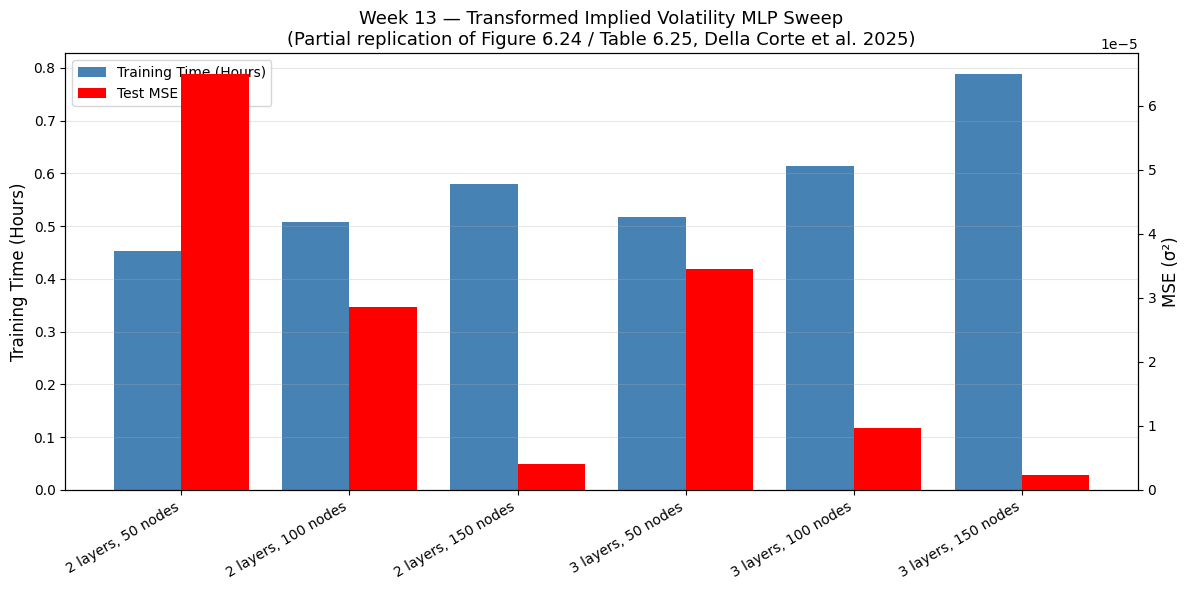

Saved: runs/week13_transformed_iv_mlp_sweep/20260517-175402/figures/week13_fig6_24_style_time_vs_mse.png


In [ ]:
# =========================
# CELL 13.9 — Figure 6.24-Style Dual-Axis Bar Chart
# =========================

labels      = df_w13["label"].tolist()
x           = np.arange(len(labels))
bar_w       = 0.40
train_hours = df_w13["training_hours"].values
test_mses   = df_w13["test_mse"].values

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2      = ax1.twinx()

ax1.bar(x - bar_w/2, train_hours, width=bar_w,
        label="Training Time (Hours)", color="steelblue")
ax2.bar(x + bar_w/2, test_mses,    width=bar_w,
        label="Test MSE",            color="red")

ax1.set_ylabel("Training Time (Hours)", fontsize=12)
ax2.set_ylabel("MSE (σ²)", fontsize=12)
ax1.set_title(
    "Week 13 — Transformed Implied Volatility MLP Sweep\n"
    "(Partial replication of Figure 6.24 / Table 6.25, "
    "Della Corte et al. 2025)",
    fontsize=13
)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=30, ha="right", fontsize=10)
ax1.grid(True, axis="y", alpha=0.3)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=10)

plt.tight_layout()
fig624_path = os.path.join(
    fig_dir_w13, "week13_fig6_24_style_time_vs_mse.png"
)
plt.savefig(fig624_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", fig624_path)

Saved: runs/week13_transformed_iv_mlp_sweep/20260517-175402/figures/week13_train_curves_2layer.png


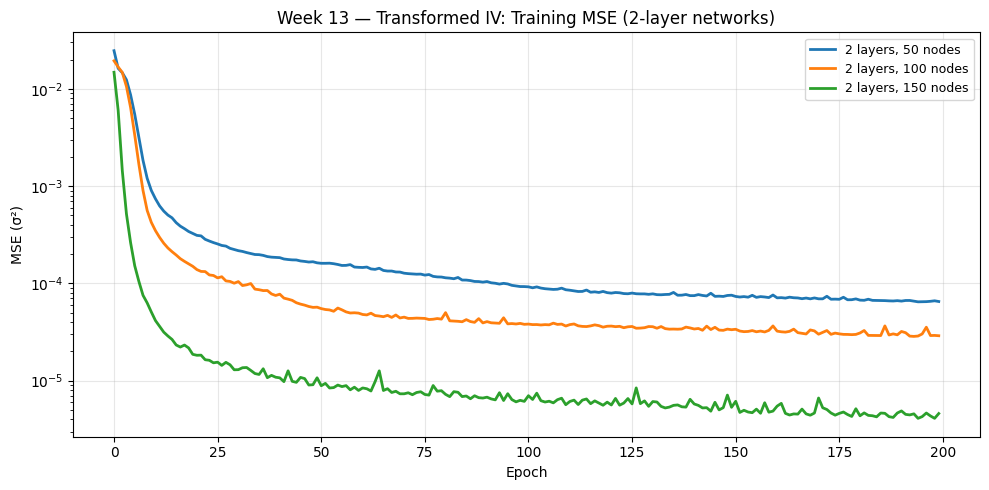

Saved: runs/week13_transformed_iv_mlp_sweep/20260517-175402/figures/week13_val_curves_2layer.png


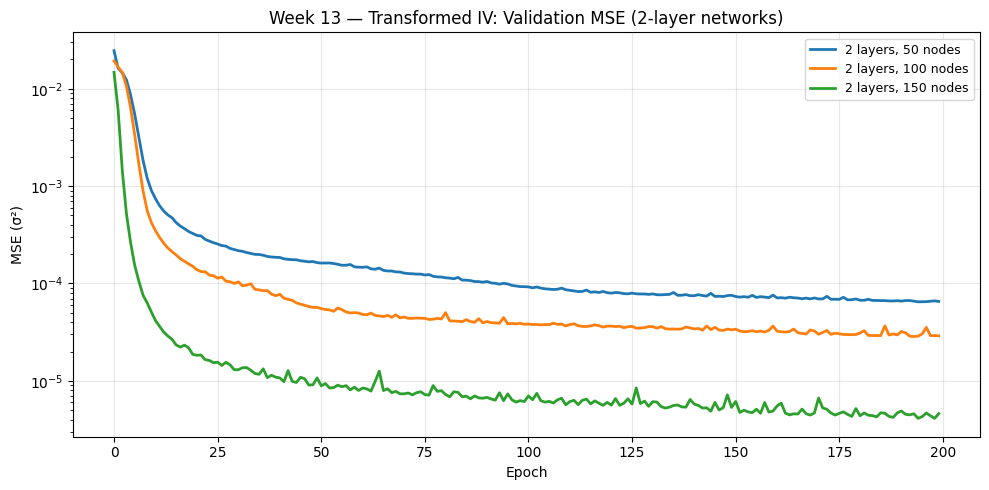

Saved: runs/week13_transformed_iv_mlp_sweep/20260517-175402/figures/week13_train_curves_3layer.png


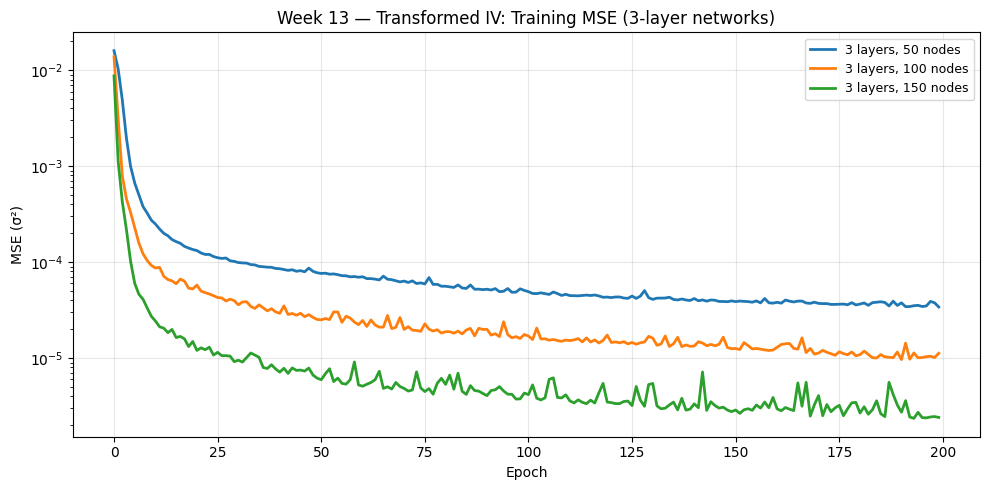

Saved: runs/week13_transformed_iv_mlp_sweep/20260517-175402/figures/week13_val_curves_3layer.png


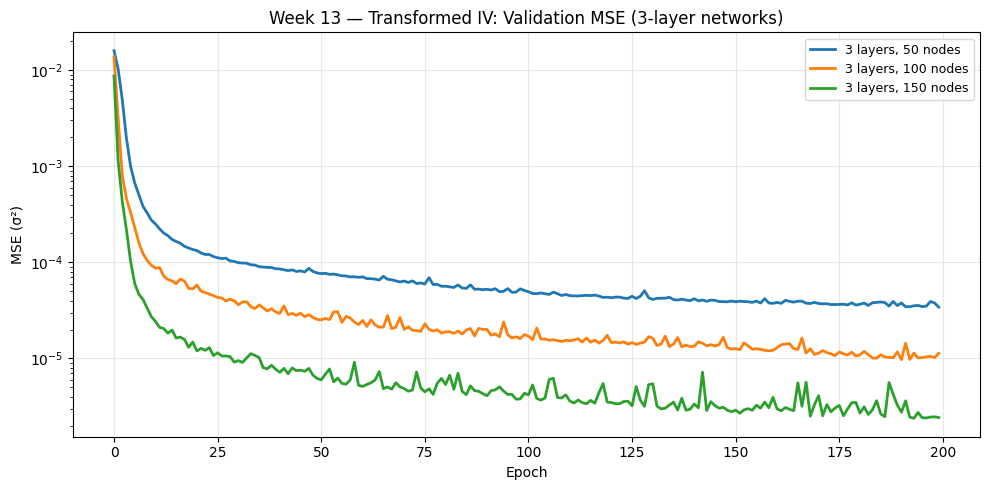

Saved: runs/week13_transformed_iv_mlp_sweep/20260517-175402/figures/week13_depth_comparison_150N_val.png


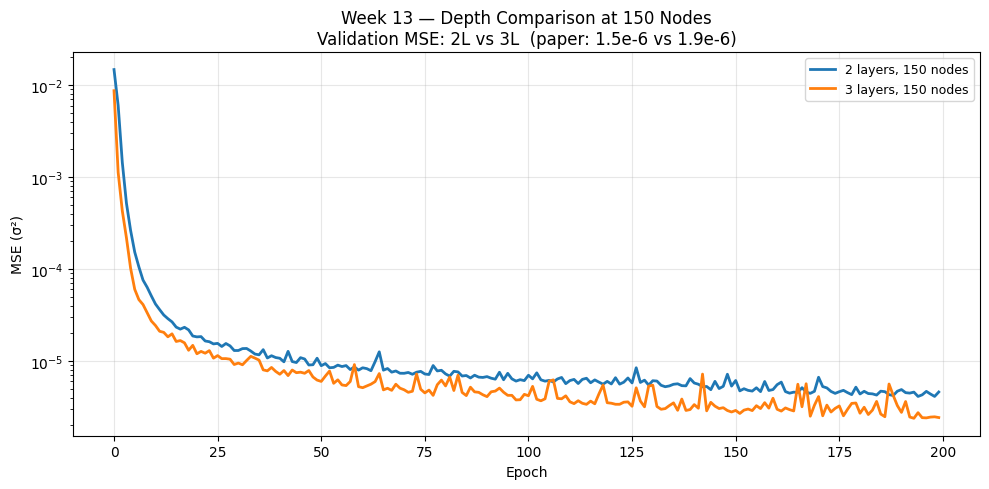

In [ ]:
# =========================
# CELL 13.10 — MSE Curves: 2-Layer vs 3-Layer Overlays
# =========================

def plot_iv_curves(df, configs, which="train_curve", title="", save_path=None):
    plt.figure(figsize=(10, 5))
    colors_c = plt.cm.tab10.colors
    for i, (L, H) in enumerate(configs):
        row = df[(df["layers"] == L) & (df["nodes"] == H)].iloc[0]
        plt.plot(row[which], color=colors_c[i], lw=2,
                 label=f"{L} layers, {H} nodes")
    plt.xlabel("Epoch")
    plt.ylabel("MSE (σ²)")
    plt.yscale("log")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=9)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=180, bbox_inches="tight")
        print("Saved:", save_path)
    plt.show()


# ── 2-layer networks ──────────────────────────────────────────────────────────
configs_2L = [(2, 50), (2, 100), (2, 150)]

plot_iv_curves(
    df_w13, configs_2L, which="train_curve",
    title="Week 13 — Transformed IV: Training MSE (2-layer networks)",
    save_path=os.path.join(fig_dir_w13, "week13_train_curves_2layer.png"),
)
plot_iv_curves(
    df_w13, configs_2L, which="val_curve",
    title="Week 13 — Transformed IV: Validation MSE (2-layer networks)",
    save_path=os.path.join(fig_dir_w13, "week13_val_curves_2layer.png"),
)

# ── 3-layer networks ──────────────────────────────────────────────────────────
configs_3L = [(3, 50), (3, 100), (3, 150)]

plot_iv_curves(
    df_w13, configs_3L, which="train_curve",
    title="Week 13 — Transformed IV: Training MSE (3-layer networks)",
    save_path=os.path.join(fig_dir_w13, "week13_train_curves_3layer.png"),
)
plot_iv_curves(
    df_w13, configs_3L, which="val_curve",
    title="Week 13 — Transformed IV: Validation MSE (3-layer networks)",
    save_path=os.path.join(fig_dir_w13, "week13_val_curves_3layer.png"),
)

# ── Depth comparison at 150 nodes ─────────────────────────────────────────────
configs_depth = [(2, 150), (3, 150)]

plot_iv_curves(
    df_w13, configs_depth, which="val_curve",
    title=(
        "Week 13 — Depth Comparison at 150 Nodes\n"
        "Validation MSE: 2L vs 3L  (paper: 1.5e-6 vs 1.9e-6)"
    ),
    save_path=os.path.join(
        fig_dir_w13, "week13_depth_comparison_150N_val.png"),
)

In [ ]:
# =========================
# CELL 13.11 — Paper Comparison Table (Our 6 Results + Paper's Remaining 6)
# =========================

PAPER_TABLE_6_25_ALL = {
    (2,  50): {"paper_hours": 0.41, "paper_mse": 1.1e-5},
    (2, 100): {"paper_hours": 0.43, "paper_mse": 2.3e-6},
    (2, 150): {"paper_hours": 0.51, "paper_mse": 1.5e-6},
    (2, 200): {"paper_hours": 0.56, "paper_mse": 1.9e-6},
    (2, 250): {"paper_hours": 0.73, "paper_mse": 6.9e-6},
    (2, 500): {"paper_hours": 1.41, "paper_mse": 3.9e-7},
    (3,  50): {"paper_hours": 0.44, "paper_mse": 4.0e-6},
    (3, 100): {"paper_hours": 0.54, "paper_mse": 5.1e-6},
    (3, 150): {"paper_hours": 0.60, "paper_mse": 1.9e-6},
    (3, 200): {"paper_hours": 0.81, "paper_mse": 1.0e-6},
    (3, 250): {"paper_hours": 0.92, "paper_mse": 2.7e-7},
    (3, 500): {"paper_hours": 2.33, "paper_mse": 1.6e-7},
}

trained_set     = set(CONFIGS_W13)
comparison_rows = []

for L in [2, 3]:
    for H in [50, 100, 150, 200, 250, 500]:
        paper  = PAPER_TABLE_6_25_ALL[(L, H)]
        is_our = (L, H) in trained_set

        if is_our:
            row_match  = df_w13[(df_w13["layers"]==L) & (df_w13["nodes"]==H)].iloc[0]
            our_mse    = float(row_match["test_mse"])
            our_hours  = float(row_match["training_hours"])
            our_params = int(row_match["n_params"])
            ratio      = round(our_mse / paper["paper_mse"], 3)
            source     = "replicated"
        else:
            our_mse    = float("nan")
            our_hours  = float("nan")
            our_params = int(PaperMLP(L, H, in_dim=4).count_params())
            ratio      = float("nan")
            source     = "paper only"

        comparison_rows.append({
            "config":             f"{L}L {H}N",
            "layers":             L,
            "nodes":              H,
            "n_params":           our_params,
            "source":             source,
            "our_hours":          our_hours,
            "paper_hours":        paper["paper_hours"],
            "our_mse":            our_mse,
            "paper_mse":          paper["paper_mse"],
            "ratio_our_vs_paper": ratio,
        })

df_compare = pd.DataFrame(comparison_rows)

print("Full Table 6.25 Comparison (replicated + paper-only rows):")
display(df_compare[[
    "config", "n_params", "source",
    "our_mse", "paper_mse", "ratio_our_vs_paper",
    "our_hours", "paper_hours",
]].to_string(index=False))

compare_csv = os.path.join(
    run_dir_w13, "week13_paper_comparison_table.csv"
)
df_compare.to_csv(compare_csv, index=False)
print("\nSaved:", compare_csv)

save_json(run_dir_w13, "paper_comparison", {
    "note": (
        "ratio_our_vs_paper < 1 means we beat the paper; > 1 means paper is better. "
        "Training times differ because the paper used a dedicated Intel Xeon 3.0 GHz "
        "cluster core. Rows marked 'paper only' were omitted to reduce compute and "
        "are taken directly from Table 6.25 of Della Corte et al. (2025)."
    ),
    "rows": comparison_rows,
})

In [ ]:
# =========================
# CELL 13.12 — Week 13 Summary
# =========================

best_our  = df_w13.loc[df_w13["test_mse"].idxmin()]
worst_our = df_w13.loc[df_w13["test_mse"].idxmax()]

replicated_rows = df_compare[df_compare["source"] == "replicated"]
paper_only_rows = df_compare[df_compare["source"] == "paper only"]

summary_w13 = f"""
WEEK 13 SUMMARY — Transformed Implied Volatility MLP Sweep
Partial replication of Table 6.25 / Figure 6.24, Della Corte et al. (2025)

================================================================
MOTIVATION
================================================================
The raw IV problem feeds π/K directly and asks the MLP to invert
Black-Scholes. The gradient dσ/dπ = 1/vega explodes wherever
vega ≈ 0 (deep ITM/OTM), causing all 12 models to plateau at
MSE ≈ 7×10⁻⁴ regardless of size (Table 6.23 in the paper).

Two-step fix (Liu et al. [22], Section 5.2):
  1. Subtract scaled intrinsic:  π̂/K = π/K − max(m − e^{{−rτ}}, 0)
  2. Log-transform:              x₄   = log(π̂/K)
Effect: 2L-150N MSE drops from 7.1×10⁻⁴ → 1.5×10⁻⁶ (~3 orders of
magnitude) with no architecture or hyperparameter changes.

================================================================
DATASET
================================================================
Source:   Synthetic BS, LHS (Table 5.11 ranges)
Train:    {n_train:,}  |  Val: {n_val:,}  |  Test: {len(X_test):,}
Features: m, τ, r, log(π̂/K)   [in_dim=4]
Label:    σ (implied volatility)
log(π̂/K) range: [{X_trainval[:,3].min():.4f}, {X_trainval[:,3].max():.4f}]
Paper Table 5.14 expected: [-18.42, -0.95]

================================================================
HYPERPARAMETERS
================================================================
Activation: ReLU | Loss: MSE | Init: Xavier Normal (Glorot)
LR: {PAPER_LR} | Batch: {PAPER_BATCH} | Epochs: {PAPER_EPOCHS} | Adam ε: {ADAM_EPS}
Device: CPU, 1 thread

================================================================
CONFIGS TRAINED (6 of 12) — RATIONALE
================================================================
2L  50N  baseline floor
2L 100N  first jump in 2-layer series
2L 150N  Week 7 architecture (cross-week continuity)
3L  50N  3-layer floor; depth comparison vs 2L-50N
3L 100N  mirrors 2L-100N for depth comparison
3L 150N  direct depth comparison vs 2L-150N

Omitted (taken from Table 6.25):
{chr(10).join(f"  {r['config']}" for _, r in paper_only_rows.iterrows())}

================================================================
OUR RESULTS vs TABLE 6.25
================================================================
{replicated_rows[['config','n_params','our_mse','paper_mse','ratio_our_vs_paper']].to_string(index=False)}

Best (ours):  {int(best_our['layers'])}L {int(best_our['nodes'])}N  |  test MSE = {best_our['test_mse']:.3e}
Worst (ours): {int(worst_our['layers'])}L {int(worst_our['nodes'])}N  |  test MSE = {worst_our['test_mse']:.3e}
Paper best:   3L 500N  |  1.6e-07

================================================================
ARTIFACTS
================================================================
Dataset summary:          {os.path.join(run_dir_w13, 'dataset_summary.json')}
EDA distributions:        {eda_path}
Sweep results CSV:        {csv_path_w13}
Figure 6.24 replica:      {fig624_path}
Full comparison table:    {compare_csv}
Per-model curves:         {fig_dir_w13}/week13_*_epoch_vs_mse.png
2L / 3L overlays:         {fig_dir_w13}/week13_train/val_curves_*.png
Depth comparison (150N):  {fig_dir_w13}/week13_depth_comparison_150N_val.png
""".strip()

print(summary_w13)

summary_path = os.path.join(run_dir_w13, "notes_week13_summary.md")
with open(summary_path, "w") as f:
    f.write(summary_w13 + "\n")

save_json(run_dir_w13, "week13_summary", {"summary": summary_w13})
print("\nSaved summary to:", summary_path)

WEEK 13 SUMMARY — Transformed Implied Volatility MLP Sweep
Partial replication of Table 6.25 / Figure 6.24, Della Corte et al. (2025)

MOTIVATION
The raw IV problem feeds π/K directly and asks the MLP to invert
Black-Scholes. The gradient dσ/dπ = 1/vega explodes wherever
vega ≈ 0 (deep ITM/OTM), causing all 12 models to plateau at
MSE ≈ 7×10⁻⁴ regardless of size (Table 6.23 in the paper).

Two-step fix (Liu et al. [22], Section 5.2):
  1. Subtract scaled intrinsic:  π̂/K = π/K − max(m − e^{−rτ}, 0)
  2. Log-transform:              x₄   = log(π̂/K)
Effect: 2L-150N MSE drops from 7.1×10⁻⁴ → 1.5×10⁻⁶ (~3 orders of
magnitude) with no architecture or hyperparameter changes.

DATASET
Source:   Synthetic BS, LHS (Table 5.11 ranges)
Train:    800,000  |  Val: 200,000  |  Test: 100,000
Features: m, τ, r, log(π̂/K)   [in_dim=4]
Label:    σ (implied volatility)
log(π̂/K) range: [-18.9994, -0.9478]
Paper Table 5.14 expected: [-18.42, -0.95]

HYPERPARAMETERS
Activation: ReLU | Loss: MSE | Init: Xav